---
title: "Solving nonlinear equations in 1d"
subtitle: "Lecture 4: Chapter 2: Solving nonlinear equations in 1d"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

::: {.callout-note}

This lecture is based on Chapter 1 of [Fundamentals of Numerical Computation by Driscoll, Braun] which is avaliable <a href="https://fncbook.com/overview/" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    online
    <span class="visually-hidden">(opens in a new tab)</span>
  </a>

:::

## Recap 

ChimeIn: ...

In [1]:
#| include: false

# IF YOU HAVE DOWNLOADED THESE NOTES, 
# LET ME KNOW AND I'LL GIVE OUT 
# CHOCOLATE IN THE NEXT LECTURE

using Polynomials  
using Plots
using LaTeXStrings

## Simple iterations

Suppose we want to find fixed points of a continuous function $g:[a,b] \to [a,b]$. The **simple iteration** is defined by

$$
\begin{align}
    x_1 &\in [a,b] \nonumber\\
    %
    x_{n+1} &:= g(x_n).
\end{align}
$$ {#eq-simple-iteration}

::: {#lem-simple-1}

Suppose that $(x_{n}) \to \xi$ then $\xi$ is a fixed point of $g$.

::: 

::: {.proof} 

Since $(x_{n+1}) \to \xi$, we have $\xi = \lim_{n\to \infty} g(x_n) = g(\xi)$ by continuity of $g$.

:::

::: {#exm-change-sign-3}

Returning to @exr-change-sign-1 and @exr-change-sign-2 where $f(x) = e^x - 2x - 1$. Recall that finding roots of $f$ in $[1,2]$ is equivalent to finding fixed points of $g$ and $h$ as defined in @eq-L3-g-h. 

Let's see if the iterative methods $x_{n+1} = g(x_n)$ and $y_{n+1} = h(y_n)$ converge for $x_1 = y_1 = 1$: 


(x[end], y[end]) = (1.256431208625988, 6.439293542825908e-15)


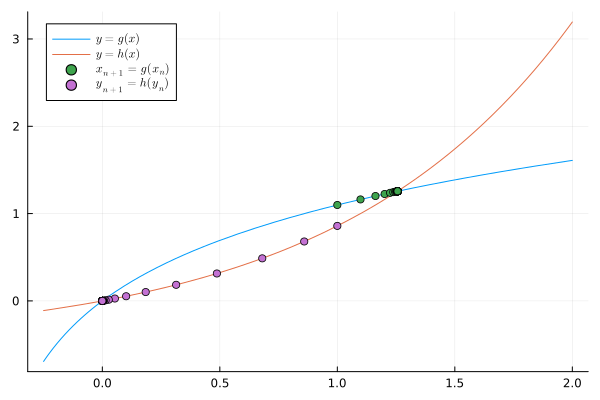

In [50]:
n_max = 15
x, y = [1.], [1.]
for n ∈ 1:50
    push!( x, g(x[end])) 
    push!( y, h(y[end])) 
end
@show (x[end], y[end]);

plot( [g, h] , -0.25, 2, label=[ L"y = g(x)" L"y = h(x)"])
plot!( x, g.(x), seriestype=:scatter, label=L"x_{n+1} = g(x_n)" )
plot!( y, h.(y), seriestype=:scatter, label=L"y_{n+1} = h(y_n)" )

Here, we see that $x_n \to \xi \approx 1.26 \in [1,2]$ but $y_{n} \to \widetilde{\xi} \approx 0$ so the formulations $g(x) = x$ and $h(x) = x$ are equivalent, but they lead to different numerical methods.

In fact, $(\xi, \tilde{\xi})$ approximate the two real roots of $f$:

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


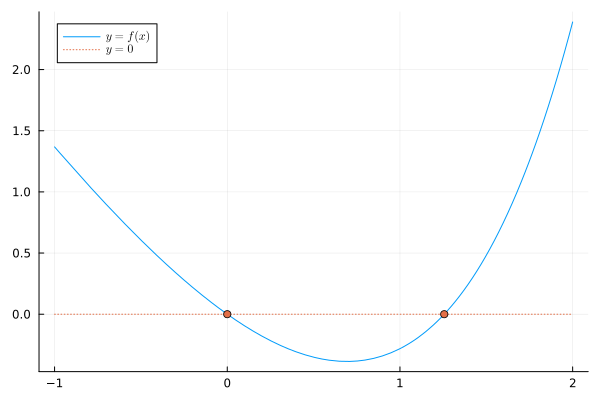

In [51]:
f = x -> exp(x) - 2*x - 1;
@show ( f(1), f(2) )

plot( f, -1, 2; label = L"y = f(x)" )
plot!( x->0; label = L"y = 0", linestyle=:dot )
scatter!( [x[end], y[end]], [0, 0]; primary=false )

:::

::: {#def-order-of-convergences}
# Order of convergence

Let $x_n \to \xi$. Suppose that there exist $\alpha\geq1$ and $\mu \geq 0$ such that

\begin{align}
    \lim_{n\to\infty}  \frac{\left|x_{n+1} - \xi\right|}{\left|x_n - \xi\right|^\alpha} = \mu
\end{align}

* If $\alpha = 1$ and $\mu \in (0,1)$, we say the convergence is *linear*,
* If $\alpha = 1$ but $\mu = 0$, we say the convergence is *superlinear* (i.e. faster than linear),
* If $\alpha = 1$ and $\mu = 1$, we say the convergence is *sublinear* (i.e slower than linear),
* If $\alpha = 2$, we say the convergence is *quadratic*,...

In the case where *(i)* $\alpha = 1, \mu \in (0,1)$ or *(ii)* $\alpha>1, \mu> 0$, we say

* $x_n \to \xi$ with *order* $\alpha$, 
* $\mu$ is the *asymptotic error constant*, and
* $\rho := - \log_{10} \mu$ is the *asymptotic rate of convergence*.

:::

* Define the errors $e_n := |x_{n}-\xi|$. Then, we have $e_{n+1} \approx \mu e_{n}^\alpha$,
* For linear convergence, $e_{N+1} \approx \mu e_N = 10^{-\rho} e_N$ and so $\rho$ measures the number of decimal digits of accuracy gained in one iteration (for sufficiently large $N$).

::: {#exm-change-sign-4}

Let's go back to our example: $f(x) = e^x - 2x - 1$. We have defined $g(x) = \log( 2x + 1 )$ and we are trying to solve the fixed point problem $g(x) = x$. 

(This is mathematically equivalent to $f(x) = 0$.)

We have seen (numerically) that $x_{n+1} = g(x_n)$ with $x_1$ converges to $\xi = g(\xi) \approx 1.26$. What is the order of convergence? What is the asymptotic error constant? Asymptotic rate of convergence?

:::

(It turns out that $\xi = g(\xi)$ can be written in terms of the LambertW function.)

In [56]:
using LambertW 
ξ = -( 1/2 + lambertw(-(1/2) * exp(-1/2), -1) )
println("ξ = $ξ")

ξ = 1.2564312086261695


In [57]:
μₙ = @. abs( ( x[2:end] - ξ )/(x[end-1] - ξ ) )
μ, ρ = μₙ[end], -log10( μₙ[end] )
println("μ = $μ")
println("ρ = $ρ")

μ = 0.5692414752957551
ρ = 0.24470346446290264


Since ``μₙ``  appears to converge to $\mu \in (0,1)$, we have $x_n \to \xi$ linearly with asymptotic error constant $\mu\approx 0.569$ and asymptotic rate of convergence $\rho \approx 0.245$. Next time, we will prove (mathematically) that $x_{n+1} = g(x_n)$ converges linearly and show that $\mu = |g'(\xi)|$. Our computed value of $\mu$ (after $15$ iterations) is close to this theoretical value: 

In [54]:
g′ = x -> 2/( 2*x + 1);
@show g′( ξ );

g′(ξ) = 0.569336274081677


::: {.callout-warning}

Missing notes: stay tuned!

:::